# Projeto Final: Classificação Homer vs Bart com Redes Neurais

**Integrante:**
* Nome: Rodrigo Prazim
* Email: rpob@cesar.school

**Dataset escolhido:** Neural Networks Homer and Bart Classification  
**Link:** https://www.kaggle.com/datasets/juniorbueno/neural-networks-homer-and-bart-classification

**Objetivo do projeto:** treinar uma Rede Neural sem camadas convolucionais para classificar imagens dos personagens Homer Simpson e Bart Simpson.

## 1. Importação dos pacotes

Nesta etapa são importadas as bibliotecas necessárias para manipulação do dataset, criação dos `DataLoaders`, definição da rede neural, treinamento, avaliação e visualização dos resultados.

In [1]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


## 2. Carregamento do dataset

O dataset utilizado contém imagens dos personagens Homer e Bart. Como os arquivos vêm inicialmente em uma única pasta, o código abaixo organiza as imagens em subpastas por classe, formato esperado pelo `ImageFolder` do PyTorch.

In [4]:
zip_file = "neural-networks-homer-and-bart-classification.zip"

if not os.path.exists(zip_file):
    !curl -L -o neural-networks-homer-and-bart-classification.zip https://www.kaggle.com/api/v1/datasets/download/juniorbueno/neural-networks-homer-and-bart-classification

In [5]:
!unzip -o neural-networks-homer-and-bart-classification.zip > /dev/null

base_dir = Path("homer_bart_1")

In [6]:
(base_dir / "homer").mkdir(exist_ok=True)
(base_dir / "bart").mkdir(exist_ok=True)

for arquivo in base_dir.glob("*.bmp"):
    nome = arquivo.name.lower()
    if "homer" in nome:
        destino = base_dir / "homer" / arquivo.name
        if not destino.exists():
            shutil.move(str(arquivo), str(destino))
    elif "bart" in nome:
        destino = base_dir / "bart" / arquivo.name
        if not destino.exists():
            shutil.move(str(arquivo), str(destino))

print("Quantidade de imagens por classe:")
for classe in ["bart", "homer"]:
    qtd = len(list((base_dir / classe).glob("*.bmp")))
    print(f"{classe}: {qtd}")

Quantidade de imagens por classe:
bart: 160
homer: 109


## 3. Manipulação e preparação dos dados

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_dataset_for_train = datasets.ImageFolder(root=str(base_dir), transform=train_transform)
full_dataset_for_test = datasets.ImageFolder(root=str(base_dir), transform=test_transform)

print("Classes encontradas:", full_dataset_for_train.classes)
print("Mapeamento classe -> índice:", full_dataset_for_train.class_to_idx)
print("Total de imagens:", len(full_dataset_for_train))

Classes encontradas: ['bart', 'homer']
Mapeamento classe -> índice: {'bart': 0, 'homer': 1}
Total de imagens: 269


In [9]:
targets = np.array([sample[1] for sample in full_dataset_for_train.samples])
indices = np.arange(len(targets))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=targets
)

train_dataset = Subset(full_dataset_for_train, train_indices)
test_dataset = Subset(full_dataset_for_test, test_indices)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Imagens de treino: {len(train_dataset)}")
print(f"Imagens de teste: {len(test_dataset)}")

Imagens de treino: 215
Imagens de teste: 54


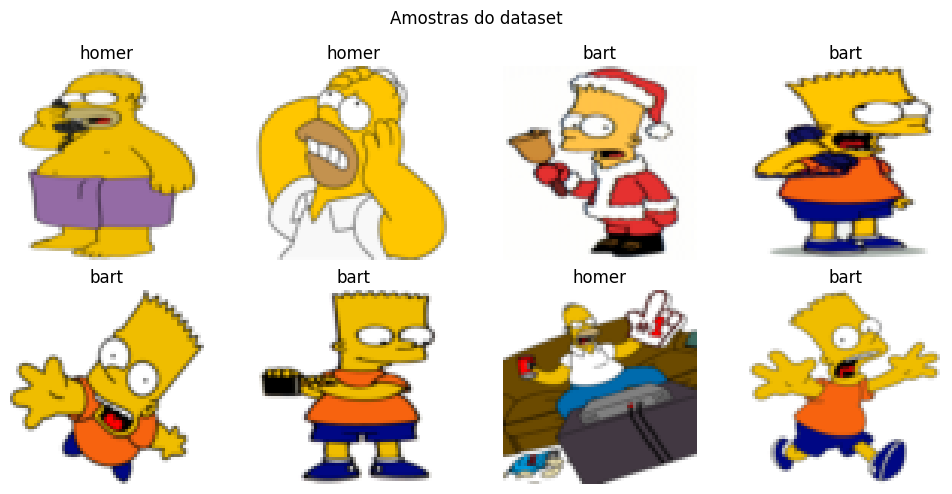

In [10]:
class_names = full_dataset_for_train.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))
for i in range(min(8, len(images))):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5  # desfaz a normalização para visualização

    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.suptitle("Amostras do dataset")
plt.tight_layout()
plt.show()

## 4. Definição do modelo da Rede Neural

Como a instrução do trabalho pede uma rede neural **sem convolução**, foi criada uma rede do tipo **MLP**, ou seja, uma rede totalmente conectada.

In [11]:
class HomerBartMLP(nn.Module):
    def __init__(self):
        super(HomerBartMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(3 * 64 * 64, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.network(x)

model = HomerBartMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)

HomerBartMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=512, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=2, bias=True)
  )
)


## 5. Funções de treinamento e avaliação

Abaixo são definidas funções para treinar e avaliar o modelo a cada época. Além da perda, também é calculada a acurácia para acompanhar a evolução do treinamento.

In [12]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, all_labels, all_predictions

## 6. Treinamento do modelo

O modelo é treinado por várias épocas. A cada época são registrados:

In [13]:
epochs = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Época {epoch:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

Época 01/30 | Train Loss: 0.5663 | Train Acc: 0.7070 | Test Loss: 0.5146 | Test Acc: 0.7778
Época 02/30 | Train Loss: 0.4339 | Train Acc: 0.7953 | Test Loss: 0.4815 | Test Acc: 0.8148
Época 03/30 | Train Loss: 0.3310 | Train Acc: 0.8930 | Test Loss: 0.5016 | Test Acc: 0.7222
Época 04/30 | Train Loss: 0.3422 | Train Acc: 0.8465 | Test Loss: 0.5225 | Test Acc: 0.7222
Época 05/30 | Train Loss: 0.2647 | Train Acc: 0.9116 | Test Loss: 0.4968 | Test Acc: 0.7593
Época 06/30 | Train Loss: 0.2311 | Train Acc: 0.9116 | Test Loss: 0.4761 | Test Acc: 0.8333
Época 07/30 | Train Loss: 0.2132 | Train Acc: 0.9256 | Test Loss: 0.4688 | Test Acc: 0.8333
Época 08/30 | Train Loss: 0.1371 | Train Acc: 0.9674 | Test Loss: 0.4906 | Test Acc: 0.7963
Época 09/30 | Train Loss: 0.1051 | Train Acc: 0.9814 | Test Loss: 0.4729 | Test Acc: 0.7778
Época 10/30 | Train Loss: 0.1092 | Train Acc: 0.9767 | Test Loss: 0.4591 | Test Acc: 0.8148
Época 11/30 | Train Loss: 0.0905 | Train Acc: 0.9767 | Test Loss: 0.4609 | Test 

## 7. Análise da performance

Avaliação da acurácia final, a perda final, a matriz de confusão e o relatório de classificação com precision, recall e f1-score.

In [14]:
final_test_loss, final_test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Perda final no teste: {final_test_loss:.4f}")
print(f"Acurácia final no teste: {final_test_acc * 100:.2f}%")

Perda final no teste: 0.6820
Acurácia final no teste: 79.63%


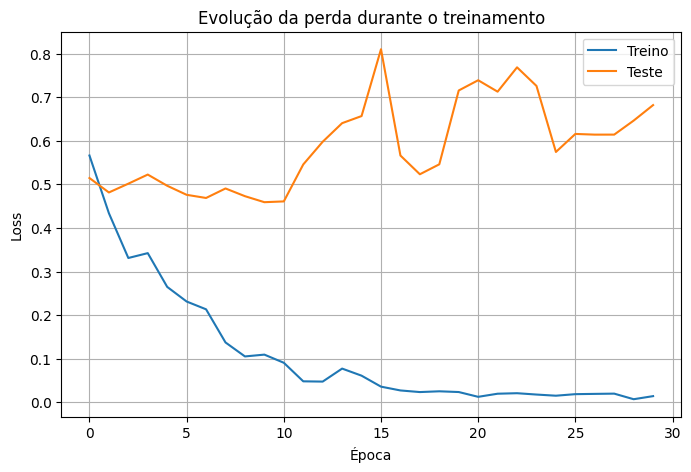

In [15]:
# Gráfico de perda
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Treino")
plt.plot(history["test_loss"], label="Teste")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolução da perda durante o treinamento")
plt.legend()
plt.grid(True)
plt.show()

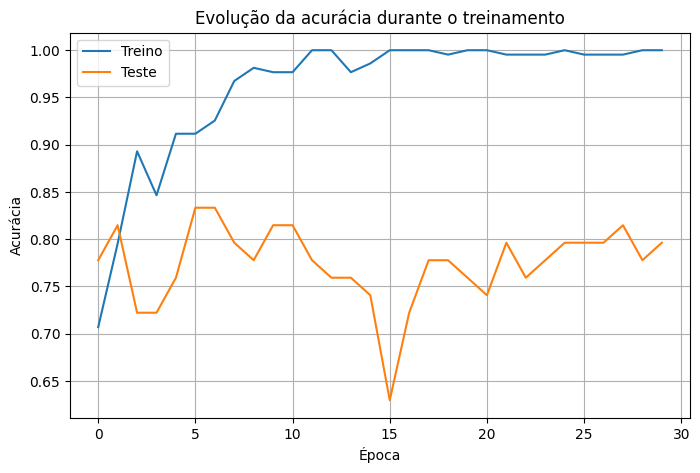

In [16]:
# Gráfico de acurácia
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Treino")
plt.plot(history["test_acc"], label="Teste")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Evolução da acurácia durante o treinamento")
plt.legend()
plt.grid(True)
plt.show()

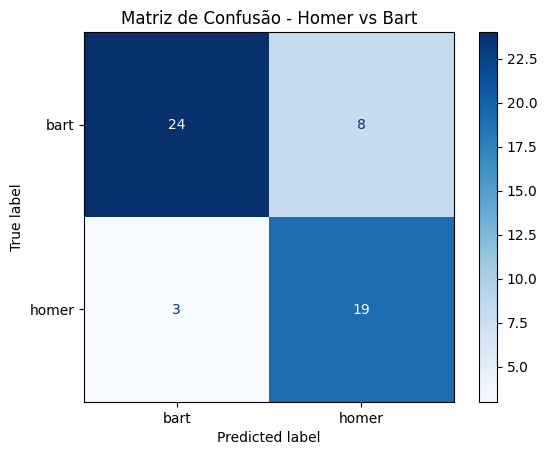

In [17]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Homer vs Bart")
plt.show()

In [18]:
# Relatório de classificação
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        bart       0.89      0.75      0.81        32
       homer       0.70      0.86      0.78        22

    accuracy                           0.80        54
   macro avg       0.80      0.81      0.79        54
weighted avg       0.81      0.80      0.80        54



## 8. Salvando o modelo treinado

O modelo treinado é salvo em um arquivo `.pt`, permitindo reutilização posterior sem necessidade de novo treinamento.

In [19]:
torch.save(model.state_dict(), "homer_bart_mlp.pt")
print("Modelo salvo como homer_bart_mlp.pt")

Modelo salvo como homer_bart_mlp.pt


## 9. Conclusão

Neste projeto foi desenvolvido um modelo de rede neural do tipo MLP para classificar imagens dos personagens Homer Simpson e Bart Simpson. O maior desafio foi adaptar um problema de classificação de imagens para uma rede sem convolução, pois imagens possuem muitos pixels e uma MLP não aproveita tão bem a estrutura espacial como uma CNN. Para melhorar o resultado, as imagens foram redimensionadas, normalizadas e separadas corretamente em treino e teste antes do treinamento. Também foram adicionados Dropout, BatchNorm e regularização com weight_decay para reduzir o risco de overfitting. Durante o treinamento, foi possível acompanhar a evolução da perda e da acurácia, além de avaliar o desempenho final com matriz de confusão e relatório de classificação. De forma geral, o modelo conseguiu aprender padrões suficientes para diferenciar as duas classes e atender ao objetivo do trabalho, mantendo a rede simples e sem camadas convolucionais.